<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">
<h1 style="margin: 0; color: #2c5f2d;">Predict the quality of the red wine on it´s quemical properties using KNN model</h1>
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Description of the problem

Train a K-Nearest Neighbors (KNN) model to predict the quality of red wine based on its chemical properties.
#### Dataset description
The dataset contains various chemical properties of red wine samples, along with a quality rating. The goal
Each row represents a wine. The columns describe its chemical composition:

**fixed acidity**, volatile acidity, citric acid

**residual sugar**, chlorides

**free sulfur dioxide**, total sulfur dioxide

**density**, pH, sulphates, alcohol

The **target column** is label:

0 = Low quality

1 = Medium quality

2 = High quality

</div>

In [1]:
# Manipulación y análisis de datos
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


# Librerías para preprocesamiento y Machine Learning 
from sklearn.preprocessing import  StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


from imblearn.over_sampling import SMOTE


# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Establecer estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("¡Librerías importadas exitosamente!")


¡Librerías importadas exitosamente!


In [2]:
# Load preprocessed data
df = pd.read_csv('../data/raw/wine/winequality-red.csv',sep=';')
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [3]:
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">
    
Revisando la calidad de los datos.
- Completitud (valores nulos)
- Duplicados
- Distribución de variables
- Balanceo de clases
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">
    Categorical the target variable into 3 classes: low, medium, high quality. This will make it a classification problem instead of regression.
</div>

In [4]:
# Create quality categories: Low (3-4), Medium (6), High (7-8)
df['quality_label'] = pd.cut(df['quality'], bins=[0, 4, 6, 10], 
                               labels=[0, 1, 2])

📊 INFORMACIÓN GENERAL DEL DATASET

✓ Dimensiones: 1599 filas × 13 columnas

✓ Tamaño en memoria: 0.15 MB

--------------------------------------------------------------------------------
Tipos de datos:
--------------------------------------------------------------------------------
fixed acidity            float64
volatile acidity         float64
citric acid              float64
residual sugar           float64
chlorides                float64
free sulfur dioxide      float64
total sulfur dioxide     float64
density                  float64
pH                       float64
sulphates                float64
alcohol                  float64
quality                    int64
quality_label           category
dtype: object

--------------------------------------------------------------------------------
Primeras filas:
--------------------------------------------------------------------------------


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1



ANÁLISIS DE VALORES NULOS
Empty DataFrame
Columns: [Columna, Valores Nulos, Porcentaje (%)]
Index: []

¡Excelente! No hay valores nulos en el dataset

ANÁLISIS DE VALORES DUPLICADOS

✓ Filas duplicadas: 240
✓ Porcentaje: 15.01%

Se encontraron 240 filas duplicadas
Muestra de duplicados:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
9,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,1
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,1
22,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5,1
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5,1
39,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5,1
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5,1
64,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5,1
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5,1



ESTADÍSTICAS DESCRIPTIVAS


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000



DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

Distribución de 'quality' (original):
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Distribución de 'quality_label' (categorizada):
quality_label
0      63
1    1319
2     217
Name: count, dtype: int64

Porcentajes:
quality_label
0     3.94
1    82.49
2    13.57
Name: count, dtype: float64


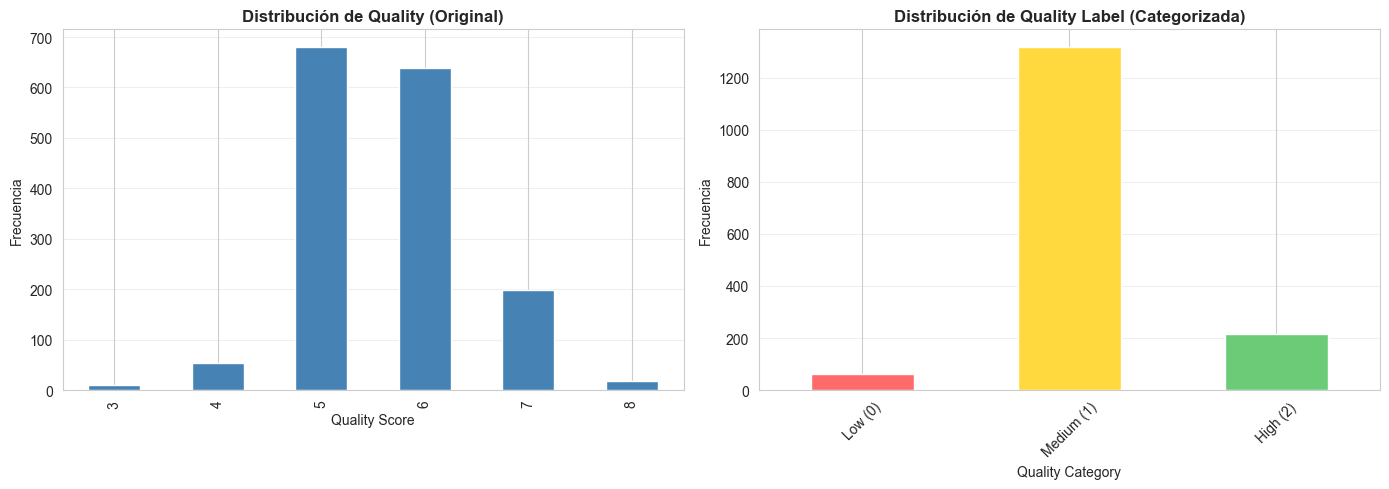


--------------------------------------------------------------------------------
ANÁLISIS DE BALANCEO DE CLASES
--------------------------------------------------------------------------------
✓ Ratio de desbalanceo: 20.94:1
El dataset está DESBALANCEADO. Considerar técnicas como SMOTE.

DETECCIÓN DE OUTLIERS (Método IQR)


,Variable,Q1,Q3,IQR,Límite Inferior,Límite Superior,Outliers,Porcentaje (%)
3,residual sugar,1.9000,2.600000,0.700000,0.850000,3.650000,155,9.693558
4,chlorides,0.0700,0.090000,0.020000,0.040000,0.120000,112,7.004378
9,sulphates,0.5500,0.730000,0.180000,0.280000,1.000000,59,3.689806
6,total sulfur dioxide,22.0000,62.000000,40.000000,-38.000000,122.000000,55,3.439650
0,fixed acidity,7.1000,9.200000,2.100000,3.950000,12.350000,49,3.064415
7,density,0.9956,0.997835,0.002235,0.992248,1.001187,45,2.814259
8,pH,3.2100,3.400000,0.190000,2.925000,3.685000,35,2.188868
5,free sulfur dioxide,7.0000,21.000000,14.000000,-14.000000,42.000000,30,1.876173
1,volatile acidity,0.3900,0.640000,0.250000,0.015000,1.015000,19,1.188243
10,alcohol,9.5000,11.100000,1.600000,7.100000,13.500000,13,0.813008



Variables con mayor cantidad de outliers:
               Variable  Outliers  Porcentaje (%)
3        residual sugar       155        9.693558
4             chlorides       112        7.004378
9             sulphates        59        3.689806
6  total sulfur dioxide        55        3.439650
0         fixed acidity        49        3.064415


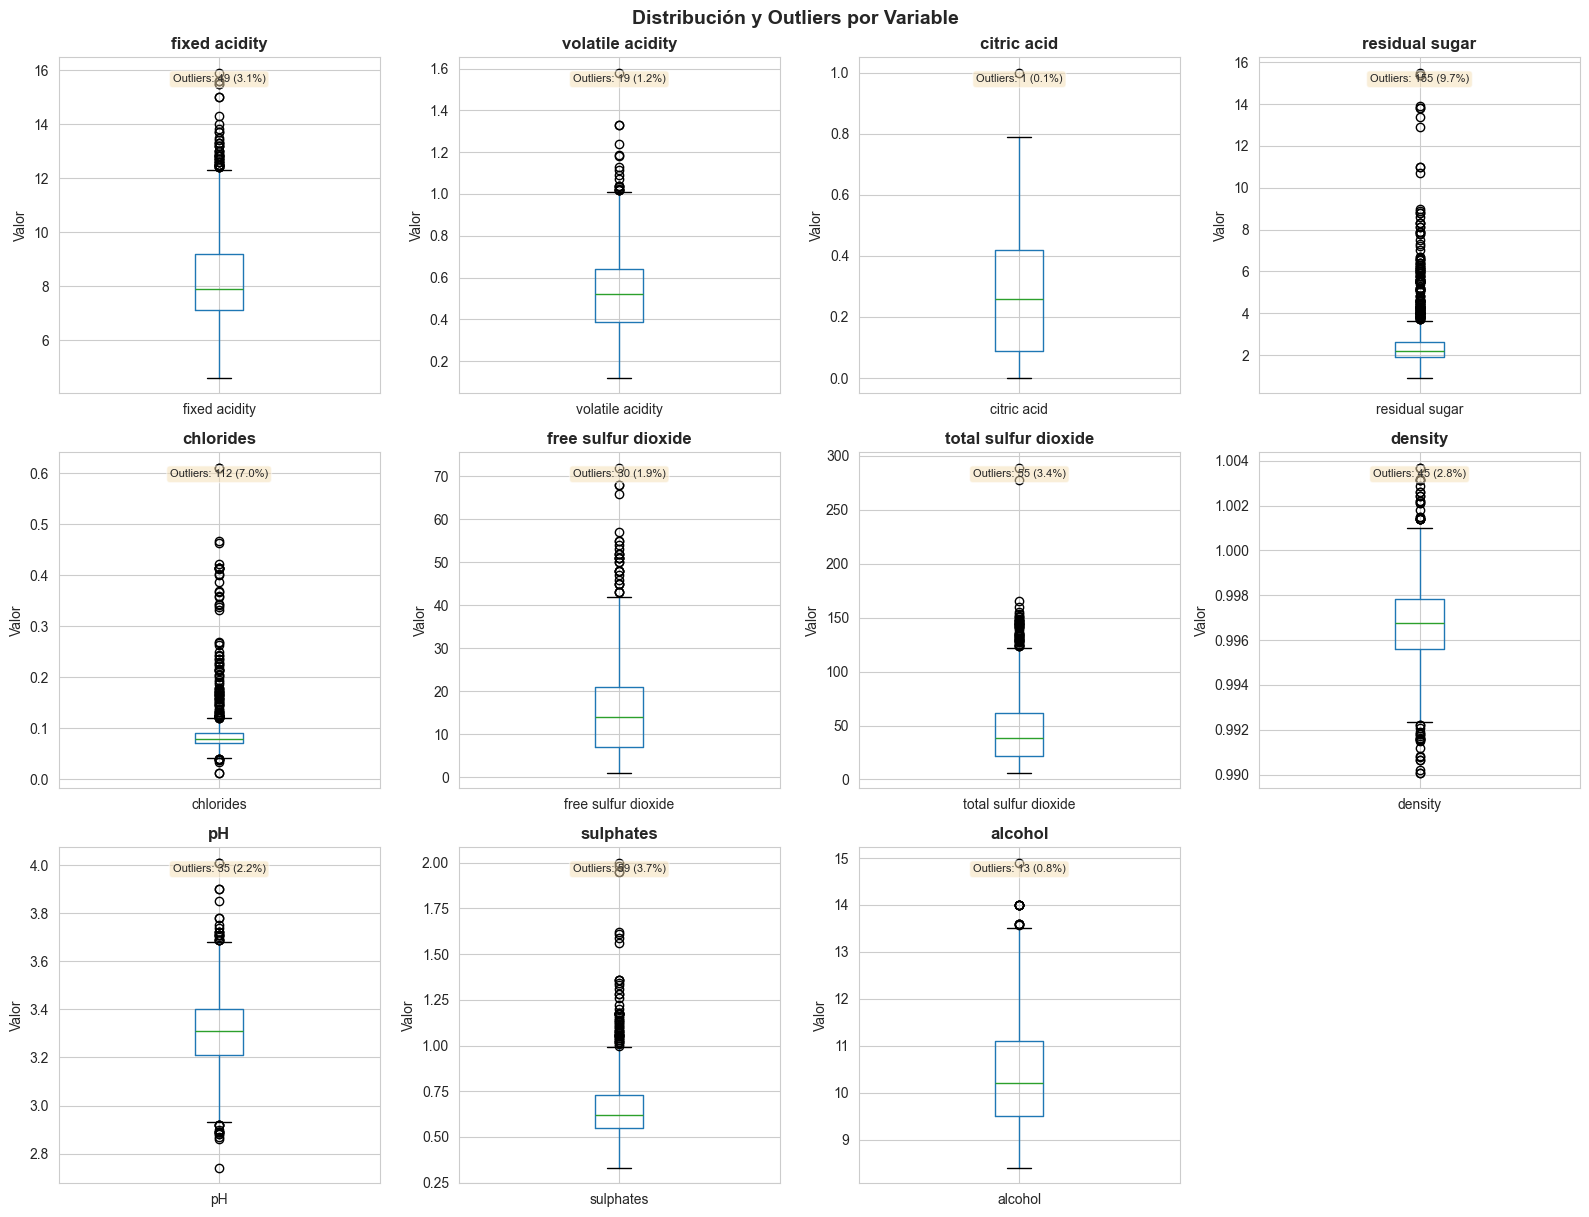


RESUMEN DE CALIDAD DE DATOS

Dataset: 1599 filas × 13 columnas
Valores nulos: 0 (0.00%)
Filas duplicadas: 240 (15.01%)
Desbalanceo de clases: 20.94:1
Variables con outliers: 11 de 11
Total de outliers detectados: 573 (35.83% del dataset)

RECOMENDACIONES PARA KNN:
   1. No hay valores nulos - No se requiere imputación
   2. Eliminar duplicados antes del modelado
   3. Aplicar SMOTE u otra técnica para balancear clases
   4. Normalizar/Escalar features (KNN es sensible a escalas)
   5. Considerar si remover o transformar outliers (probar ambos enfoques)
   6. Revisar correlaciones para evitar multicolinealidad



In [5]:
# ==========================================
# 1. INFORMACIÓN GENERAL DEL DATASET
# ==========================================
print("="*80)
print("📊 INFORMACIÓN GENERAL DEL DATASET")
print("="*80)
print(f"\n✓ Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\n✓ Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "-"*80)
print("Tipos de datos:")
print("-"*80)
print(df.dtypes)

print("\n" + "-"*80)
print("Primeras filas:")
print("-"*80)
display(df.head())

# ==========================================
# 2. COMPLETITUD - VALORES NULOS
# ==========================================
print("\n" + "="*80)
print("ANÁLISIS DE VALORES NULOS")
print("="*80)

missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Columna': missing_values.index,
    'Valores Nulos': missing_values.values,
    'Porcentaje (%)': missing_percentage.values
})

print(missing_df[missing_df['Valores Nulos'] > 0])

if missing_df['Valores Nulos'].sum() == 0:
    print("\n¡Excelente! No hay valores nulos en el dataset")
else:
    print(f"\nTotal de valores nulos: {missing_df['Valores Nulos'].sum()}")

# ==========================================
# 3. VALORES DUPLICADOS
# ==========================================
print("\n" + "="*80)
print("ANÁLISIS DE VALORES DUPLICADOS")
print("="*80)

duplicates = df.duplicated().sum()
print(f"\n✓ Filas duplicadas: {duplicates}")
print(f"✓ Porcentaje: {(duplicates/len(df)*100):.2f}%")

if duplicates > 0:
    print(f"\nSe encontraron {duplicates} filas duplicadas")
    print("Muestra de duplicados:")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("\nNo hay filas duplicadas")

# ==========================================
# 4. ESTADÍSTICAS DESCRIPTIVAS
# ==========================================
print("\n" + "="*80)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*80)
display(df.describe())

# ==========================================
# 5. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ==========================================
print("\n" + "="*80)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("="*80)

print("\nDistribución de 'quality' (original):")
print(df['quality'].value_counts().sort_index())

print("\nDistribución de 'quality_label' (categorizada):")
label_counts = df['quality_label'].value_counts().sort_index()
print(label_counts)
print("\nPorcentajes:")
print((label_counts / len(df) * 100).round(2))

# Visualización de la distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quality original
df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de Quality (Original)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

# Quality_label
quality_labels = ['Low (0)', 'Medium (1)', 'High (2)']
label_counts.plot(kind='bar', ax=axes[1], color=['#FF6B6B', '#FFD93D', '#6BCB77'])
axes[1].set_title('Distribución de Quality Label (Categorizada)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quality Category')
axes[1].set_ylabel('Frecuencia')
axes[1].set_xticklabels(quality_labels, rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de desbalanceo
print("\n" + "-"*80)
print("ANÁLISIS DE BALANCEO DE CLASES")
print("-"*80)
class_balance = label_counts.max() / label_counts.min()
print(f"✓ Ratio de desbalanceo: {class_balance:.2f}:1")
if class_balance > 3:
    print("El dataset está DESBALANCEADO. Considerar técnicas como SMOTE.")
else:
    print("El dataset está relativamente balanceado.")

# ==========================================
# 6. DETECCIÓN DE OUTLIERS
# ==========================================
print("\n" + "="*80)
print("DETECCIÓN DE OUTLIERS (Método IQR)")
print("="*80)

# Excluir las columnas categóricas
numeric_cols = df.select_dtypes(include=[np.number]).drop(['quality', 'quality_label'], axis=1, errors='ignore').columns

outliers_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count = len(outliers)
    outliers_percentage = (outliers_count / len(df)) * 100
    
    outliers_summary.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Límite Inferior': lower_bound,
        'Límite Superior': upper_bound,
        'Outliers': outliers_count,
        'Porcentaje (%)': outliers_percentage
    })

outliers_df = pd.DataFrame(outliers_summary)
outliers_df = outliers_df.sort_values('Outliers', ascending=False)
display(outliers_df)

print(f"\nVariables con mayor cantidad de outliers:")
print(outliers_df.nlargest(5, 'Outliers')[['Variable', 'Outliers', 'Porcentaje (%)']])

# Visualización de outliers con boxplots
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[idx])
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_ylabel('Valor')
    
    # Añadir información de outliers
    outlier_info = outliers_df[outliers_df['Variable'] == col].iloc[0]
    axes[idx].text(0.5, 0.95, f"Outliers: {int(outlier_info['Outliers'])} ({outlier_info['Porcentaje (%)']:.1f}%)",
                   transform=axes[idx].transAxes, ha='center', va='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=8)

# Ocultar ejes sobrantes
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Distribución y Outliers por Variable', y=1.01, fontsize=14, fontweight='bold')
plt.show()

# ==========================================
# 7. RESUMEN FINAL DE CALIDAD DE DATOS
# ==========================================
print("\n" + "="*80)
print("RESUMEN DE CALIDAD DE DATOS")
print("="*80)

print(f"""
Dataset: {df.shape[0]} filas × {df.shape[1]} columnas
Valores nulos: {missing_df['Valores Nulos'].sum()} ({(missing_df['Valores Nulos'].sum()/df.shape[0]/df.shape[1]*100):.2f}%)
Filas duplicadas: {duplicates} ({(duplicates/len(df)*100):.2f}%)
Desbalanceo de clases: {class_balance:.2f}:1
Variables con outliers: {(outliers_df['Outliers'] > 0).sum()} de {len(numeric_cols)}
Total de outliers detectados: {outliers_df['Outliers'].sum()} ({(outliers_df['Outliers'].sum()/len(df)*100):.2f}% del dataset)

RECOMENDACIONES PARA KNN:
   1. No hay valores nulos - No se requiere imputación
   {'2. Eliminar duplicados antes del modelado' if duplicates > 0 else '2. No hay duplicados'}
   {'3. Aplicar SMOTE u otra técnica para balancear clases' if class_balance > 3 else '3. Las clases están relativamente balanceadas'}
   4. Normalizar/Escalar features (KNN es sensible a escalas)
   5. Considerar si remover o transformar outliers (probar ambos enfoques)
   6. Revisar correlaciones para evitar multicolinealidad
""")


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">
Elimino los duplicados y aplico la technica SMOTE para balancear las clases.
</div>

In [6]:
df = df.drop_duplicates().reset_index(drop=True)

print(df.shape)

df["quality_label"].value_counts().sort_index()

(1359, 13)


quality_label
0      63
1    1112
2     184
Name: count, dtype: int64

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">
    After checking the ouliers don´t improve the model, I decide not remove the ouliers and apply the KNN directly to the data.
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">
    Now, I am going to check the correlation among the variables.
</div>

In [7]:
# Correlation matrix
numeric_features = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_features].corr()
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


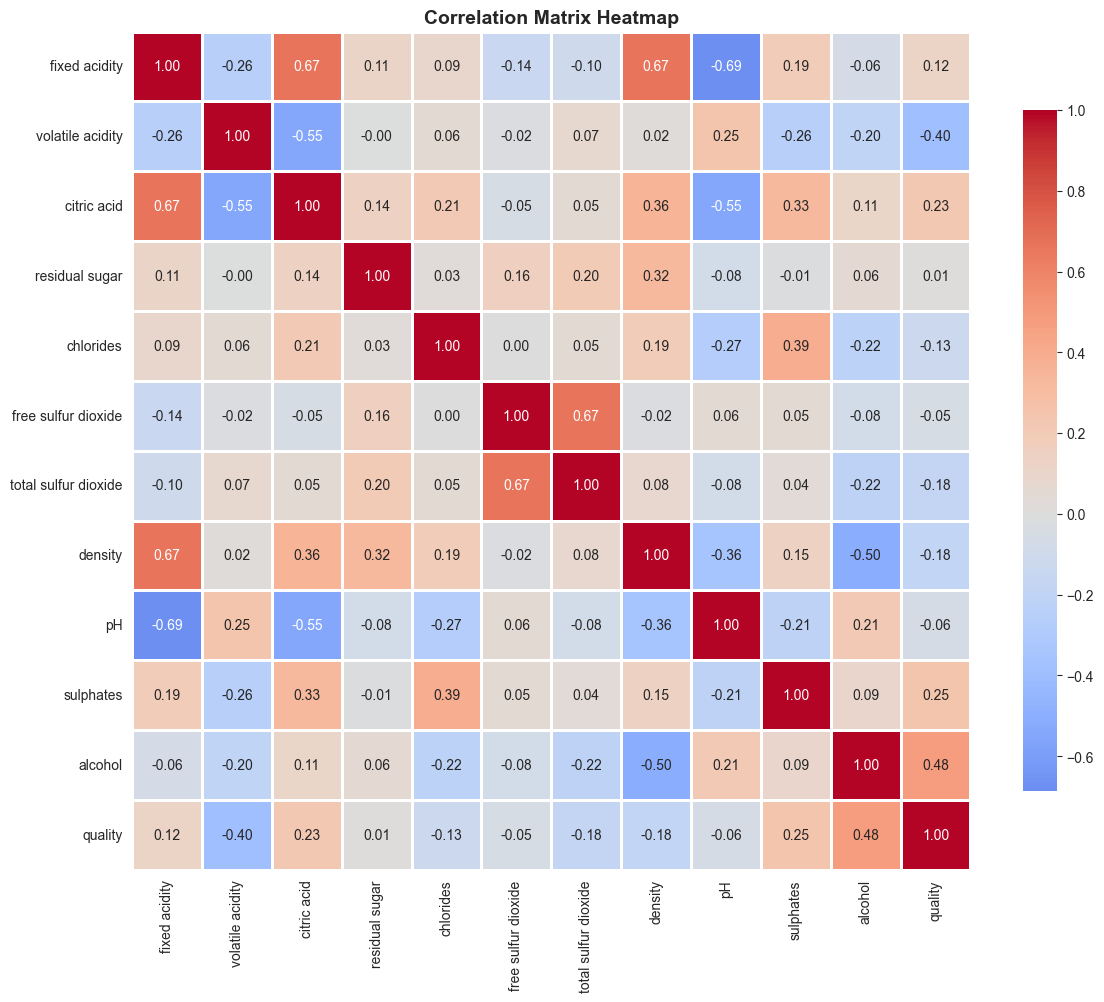


Identify strong correlations (|r| > 0.65)
• fixed acidity        <-> citric acid          | r =  0.667
• fixed acidity        <-> density              | r =  0.670
• fixed acidity        <-> pH                   | r = -0.687
• free sulfur dioxide  <-> total sulfur dioxide | r =  0.667


In [8]:
# Visualize correlation matrix with heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify strong correlations
print("\n" + "="*70)
print("Identify strong correlations (|r| > 0.65)")
print("="*70)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.65:
            print(f"• {correlation_matrix.columns[i]:20} <-> {correlation_matrix.columns[j]:20} | r = {correlation_matrix.iloc[i, j]:>6.3f}")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">
    No hay mucha correlación entre las variables, se podria considerar  eliminar 'pH', 'free sulfur dioxide', 'citric acid'. Inicialmente no las elimino, pero si el modelo no mejora, las eliminaré y volveré a entrenar el modelo.
</div>

In [9]:
# Remove highly correlated features
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']


In [10]:
print(y.value_counts().sort_index())

# Percentage distribution
print(y.value_counts(normalize=True).sort_index() * 100)

quality_label
0      63
1    1112
2     184
Name: count, dtype: int64
quality_label
0     4.635762
1    81.824871
2    13.539367
Name: proportion, dtype: float64


Aplico la separacion de variables independientes y dependientes, y la normalizacion de los datos.

In [11]:

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("y_train:")
print(y_train.value_counts().sort_index())
print("y_test:")
print(y_test.value_counts().sort_index())

X_train: (1087, 11)
X_test: (272, 11)
y_train:
quality_label
0     48
1    889
2    150
Name: count, dtype: int64
y_test:
quality_label
0     15
1    223
2     34
Name: count, dtype: int64


Aplico SMOTE para balancear las clases.

In [13]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
# Check the new distribution
print("Before SMOTE:", y_train.value_counts().sort_index())
print("After SMOTE:", pd.Series(y_train_resampled).value_counts().sort_index())


Before SMOTE: quality_label
0     48
1    889
2    150
Name: count, dtype: int64
After SMOTE: quality_label
0    889
1    889
2    889
Name: count, dtype: int64


# Feature Selection

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_resampled, y_train_resampled)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
y_pred_euclidean = knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred_euclidean))
print(confusion_matrix(y_test, y_pred_euclidean))

              precision    recall  f1-score   support

           0       0.21      0.47      0.29        15
           1       0.89      0.60      0.72       223
           2       0.28      0.74      0.41        34

    accuracy                           0.61       272
   macro avg       0.46      0.60      0.47       272
weighted avg       0.78      0.61      0.65       272

[[  7   7   1]
 [ 27 133  63]
 [  0   9  25]]


In [16]:
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train_resampled, y_train_resampled)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [17]:
y_pred_manhattan = knn_manhattan.predict(X_test_scaled)
print(classification_report(y_test, y_pred_manhattan))
print(confusion_matrix(y_test, y_pred_manhattan))

              precision    recall  f1-score   support

           0       0.21      0.47      0.29        15
           1       0.92      0.61      0.73       223
           2       0.29      0.79      0.43        34

    accuracy                           0.62       272
   macro avg       0.47      0.62      0.48       272
weighted avg       0.81      0.62      0.67       272

[[  7   5   3]
 [ 26 135  62]
 [  1   6  27]]



--------------------------------------------------------------------------------
ACCURACY SCORE
--------------------------------------------------------------------------------
KNN Euclidean (default):  0.6066 (60.66%)
KNN Manhattan:            0.6213 (62.13%)
Diferencia:               0.0147
Mejor: KNN Manhattan (+1.47%)

--------------------------------------------------------------------------------
CLASSIFICATION REPORT
--------------------------------------------------------------------------------

KNN EUCLIDEAN (default):
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

     Low (0)       0.21      0.47      0.29        15
  Medium (1)       0.89      0.60      0.72       223
    High (2)       0.28      0.74      0.41        34

    accuracy                           0.61       272
   macro avg       0.46      0.60      0.47       272
weighted avg       0.78      0.61      0.65       272


K

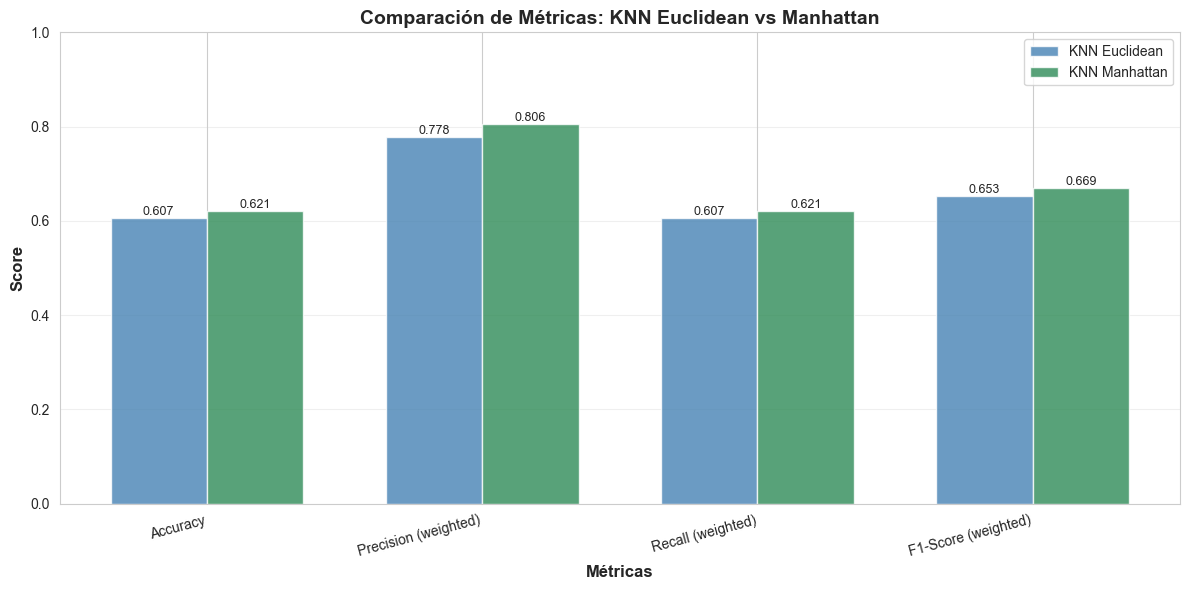


CONCLUSIÓN

Modelo ganador: KNN Manhattan
   F1-Score: 0.6692
   Ventaja: +1.64%

   ⚡ Usa KNN Manhattan para este dataset


In [18]:

# ==========================================
# 1. ACCURACY SCORE
# ==========================================
acc_euclidean = accuracy_score(y_test, y_pred_euclidean)
acc_manhattan = accuracy_score(y_test, y_pred_manhattan)

print("\n" + "-"*80)
print("ACCURACY SCORE")
print("-"*80)
print(f"KNN Euclidean (default):  {acc_euclidean:.4f} ({acc_euclidean*100:.2f}%)")
print(f"KNN Manhattan:            {acc_manhattan:.4f} ({acc_manhattan*100:.2f}%)")
print(f"Diferencia:               {abs(acc_euclidean - acc_manhattan):.4f}")
if acc_euclidean > acc_manhattan:
    print(f"Mejor: KNN Euclidean (+{((acc_euclidean - acc_manhattan)*100):.2f}%)")
elif acc_manhattan > acc_euclidean:
    print(f"Mejor: KNN Manhattan (+{((acc_manhattan - acc_euclidean)*100):.2f}%)")
else:
    print("Ambos modelos tienen el mismo accuracy")

# ==========================================
# 2. CLASSIFICATION REPORT
# ==========================================
print("\n" + "-"*80)
print("CLASSIFICATION REPORT")
print("-"*80)

print("\nKNN EUCLIDEAN (default):")
print("-"*80)
print(classification_report(y_test, y_pred_euclidean, 
                          target_names=['Low (0)', 'Medium (1)', 'High (2)']))

print("\nKNN MANHATTAN:")
print("-"*80)
print(classification_report(y_test, y_pred_manhattan, 
                          target_names=['Low (0)', 'Medium (1)', 'High (2)']))


# ==========================================
# 3. CONFUSION MATRIX
# ==========================================
cm_euclidean = confusion_matrix(y_test, y_pred_euclidean)
cm_manhattan = confusion_matrix(y_test, y_pred_manhattan)

print("\n" + "-"*80)
print("CONFUSION MATRIX")
print("-"*80)

print("\nKNN Euclidean - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_euclidean))
print("\nKNN Manhattan - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_manhattan))


# ==========================================
# 4. MÉTRICAS COMPARATIVAS
# ==========================================
print("\n" + "="*80)
print("📈 RESUMEN COMPARATIVO DE MÉTRICAS")
print("="*80)

# Obtener métricas detalladas
precision_euc = precision_score(y_test, y_pred_euclidean, average='weighted')
recall_euc = recall_score(y_test, y_pred_euclidean, average='weighted')
f1_euc = f1_score(y_test, y_pred_euclidean, average='weighted')

precision_man = precision_score(y_test, y_pred_manhattan, average='weighted')
recall_man = recall_score(y_test, y_pred_manhattan, average='weighted')
f1_man = f1_score(y_test, y_pred_manhattan, average='weighted')

# Crear DataFrame comparativo
comparison_df = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)'],
    'KNN Euclidean': [acc_euclidean, precision_euc, recall_euc, f1_euc],
    'KNN Manhattan': [acc_manhattan, precision_man, recall_man, f1_man],
    'Diferencia': [
        abs(acc_euclidean - acc_manhattan),
        abs(precision_euc - precision_man),
        abs(recall_euc - recall_man),
        abs(f1_euc - f1_man)
    ]
})

print("\n" + comparison_df.to_string(index=False))

# Visualización de barras comparativas
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df['Métrica']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['KNN Euclidean'], width, 
               label='KNN Euclidean', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['KNN Manhattan'], width, 
               label='KNN Manhattan', color='seagreen', alpha=0.8)

ax.set_xlabel('Métricas', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Métricas: KNN Euclidean vs Manhattan', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Métrica'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ==========================================
# 5. CONCLUSIÓN
# ==========================================
print("\n" + "="*80)
print("CONCLUSIÓN")
print("="*80)

if f1_euc > f1_man:
    winner = "KNN Euclidean"
    diff = (f1_euc - f1_man) * 100
    better_score = f1_euc
elif f1_man > f1_euc:
    winner = "KNN Manhattan"
    diff = (f1_man - f1_euc) * 100
    better_score = f1_man
else:
    winner = "Empate"
    diff = 0
    better_score = f1_euc

if winner != "Empate":
    print(f"\nModelo ganador: {winner}")
    print(f"   F1-Score: {better_score:.4f}")
    print(f"   Ventaja: +{diff:.2f}%")
else:
    print(f"\nAmbos modelos tienen rendimiento idéntico (F1-Score: {better_score:.4f})")


if abs(f1_euc - f1_man) < 0.01:
    print(f"\n   ⚡ La diferencia es mínima (<1%), ambos son prácticamente equivalentes")
    print(f"      Puedes usar cualquiera de los dos modelos.")
else:
    print(f"\n   ⚡ Usa {winner} para este dataset")

print("="*80)

Optimize k. Create a loop to test different k values (e.g., from 1 to 20).

(2667, 11)
(2667,)
(272, 11)
     k  accuracy_test
0    1       0.709559
1    2       0.716912
2    3       0.654412
3    4       0.650735
4    5       0.606618
5    6       0.617647
6    7       0.584559
7    8       0.595588
8    9       0.584559
9   10       0.584559
10  11       0.606618
11  12       0.595588
12  13       0.580882
13  14       0.577206
14  15       0.573529
15  16       0.580882
16  17       0.569853
17  18       0.577206
18  19       0.558824
19  20       0.562500


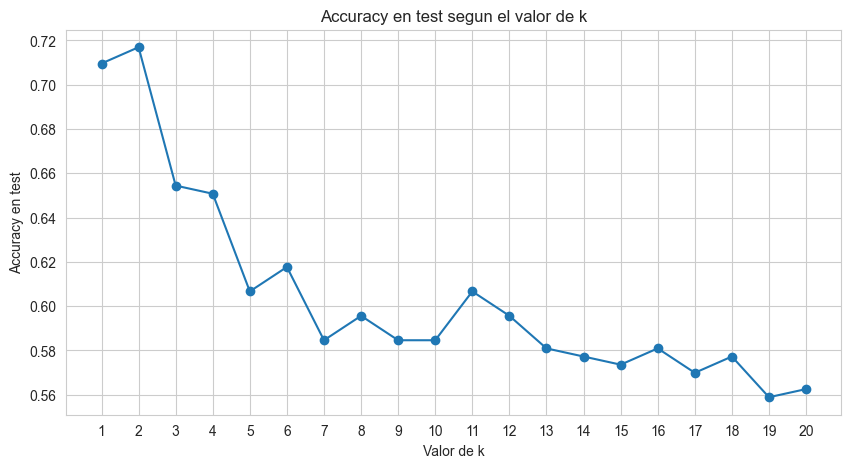

In [19]:
resultados_k = []
print(X_train_resampled.shape)
print(y_train_resampled.shape)
print(X_test_scaled.shape)

for k in range(1, 21):
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train_resampled, y_train_resampled)
    
    
    pred_test_k = modelo.predict(X_test_scaled)
    accuracy_k = accuracy_score(y_test, pred_test_k)
    
    resultados_k.append({
        "k": k,
        "accuracy_test": accuracy_k
    })

resultados_k_df = pd.DataFrame(resultados_k)
print(resultados_k_df)

plt.figure(figsize=(10, 5))
plt.plot(resultados_k_df["k"], resultados_k_df["accuracy_test"], marker="o")
plt.title("Accuracy en test segun el valor de k")
plt.xlabel("Valor de k")
plt.ylabel("Accuracy en test")
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Accuracy en este caso no es la métrica correcta

Viendo estos datos, el valor de k con mayor accuracy es k=1 (~72.5%), pero **esto es ENGAÑOSO porque al estar las clases desabalanceadas, predice bien la clase medium, pero la clase low y high no las produce

Por tanto, la mejor variable a tener en cuenta es f1-score
</div>

BÚSQUEDA DEL K ÓPTIMO (CON SMOTE)

Comparando TODAS las métricas, no solo accuracy...
--------------------------------------------------------------------------------



Tabla de resultados (primeros 10 valores de k):
--------------------------------------------------------------------------------


,k,Accuracy,Precision (Macro),Balance Recall,Recall (Clase 0),Recall (Clase 1),Recall (Clase 2),F1-Macro,F1-Weighted
0,1,0.709559,0.456674,0.516856,0.200000,0.762332,0.588235,0.473858,0.732601
1,2,0.716912,0.501498,0.602755,0.466667,0.753363,0.588235,0.529051,0.743325
2,3,0.654412,0.468743,0.589853,0.400000,0.663677,0.705882,0.488669,0.691999
3,4,0.650735,0.466265,0.592468,0.466667,0.663677,0.647059,0.486256,0.691270
4,5,0.606618,0.459800,0.599458,0.466667,0.596413,0.735294,0.469091,0.652808
5,6,0.617647,0.462832,0.603942,0.466667,0.609865,0.735294,0.472367,0.665388
6,7,0.584559,0.451952,0.590489,0.466667,0.569507,0.735294,0.452553,0.635771
7,8,0.595588,0.456571,0.607392,0.533333,0.582960,0.705882,0.461790,0.646810
8,9,0.584559,0.454284,0.602907,0.533333,0.569507,0.705882,0.455277,0.637665
9,10,0.584559,0.453188,0.602907,0.533333,0.569507,0.705882,0.453327,0.638740



K ÓPTIMO SEGÚN F1-MACRO (MÉTRICA CORRECTA)

Mejor k = 2
   F1-Macro: 0.5291
   Accuracy: 0.7169
   Precision: 0.5015
   Balance Recall: 0.6028
   Recall (Clase 0): 0.4667
   Recall (Clase 1): 0.7534
   Recall (Clase 2): 0.5882

COMPARACIÓN: k=1 (Mayor Accuracy) vs k óptimo (Mayor F1-Macro)

 k = 1:
   Accuracy:  0.7096
   F1-Macro:  0.4739

 k = 2 (RECOMENDADO):
   Accuracy:  0.7169
   F1-Macro:  0.5291

 EXPLICACIÓN

• k=1 tiene accuracy alto (70.96%) pero F1-Macro bajo (0.4739)
  → Esto significa que predice bien la clase mayoritaria (Medium)
  → Pero NO detecta bien las clases minoritarias (Low y High)
  → ¡Es OVERFITTING al vecino más cercano!

• k=2 tiene mejor balance entre TODAS las clases
  → F1-Macro más alto (0.5291)
  → Detecta mejor Low, Medium y High
  → Es más robusto y generalizable

CONCLUSIÓN: k=2 para mejores resultados generales



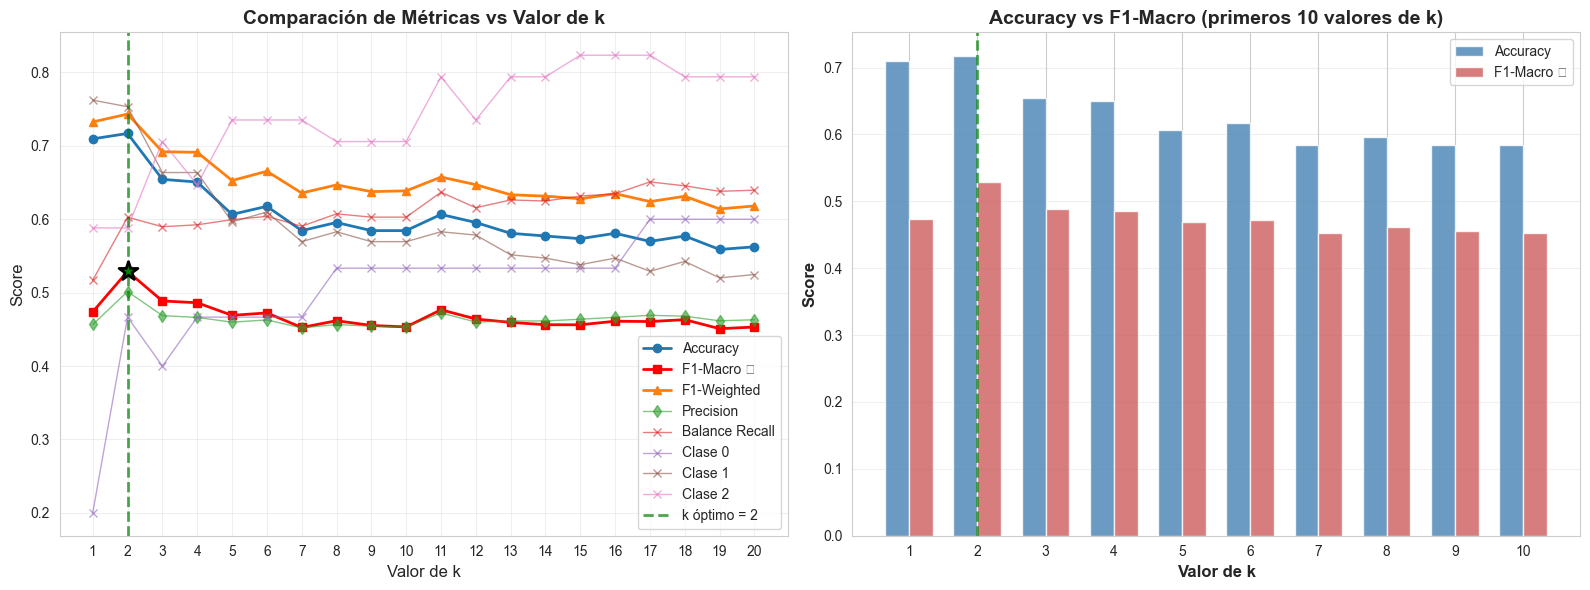


Modelo final recomendado: KNeighborsClassifier(n_neighbors=2)


In [20]:
# ==========================================
# ENCONTRAR EL K ÓPTIMO CON F1-SCORE
# ==========================================

print("="*80)
print("BÚSQUEDA DEL K ÓPTIMO (CON SMOTE)")
print("="*80)
print("\nComparando TODAS las métricas, no solo accuracy...")
print("-"*80)

resultados_completos = []

for k in range(1, 21):
    modelo = KNeighborsClassifier(n_neighbors=k)  # Usamos la métrica que tuvo mejor rendimiento
    modelo.fit(X_train_resampled, y_train_resampled)
    pred = modelo.predict(X_test_scaled)
    
    reporte = classification_report(
                y_test,
                pred,
                output_dict=True,
                zero_division=0
            )
    acc = accuracy_score(y_test, pred)
    precision_macro = precision_score(y_test, pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, pred, average='weighted', zero_division=0)
    balanced_recall = (
                reporte["0"]["recall"] +
                reporte["1"]["recall"] +
                reporte["2"]["recall"]
            ) / 3
    resultados_completos.append({
        "k": k,
        "Accuracy": acc,
        "Precision (Macro)": precision_macro,
        "Balance Recall": balanced_recall,
        "Recall (Clase 0)": reporte["0"]["recall"],
        "Recall (Clase 1)": reporte["1"]["recall"],
        "Recall (Clase 2)": reporte["2"]["recall"],
        "F1-Macro": f1_macro,
        "F1-Weighted": f1_weighted
    })

df_resultados = pd.DataFrame(resultados_completos)

# Encontrar el mejor k según F1-Macro (la métrica correcta)
mejor_idx = df_resultados['F1-Macro'].idxmax()
mejor_k = df_resultados.loc[mejor_idx, 'k']
mejor_f1 = df_resultados.loc[mejor_idx, 'F1-Macro']

print(f"\nTabla de resultados (primeros 10 valores de k):")
print("-"*80)

# Aplicar formato condicional: verde para mejores valores, amarillo para peores
def highlight_best_worst(s):
    """
    Aplica color verde a los valores máximos y amarillo a los mínimos.
    """
    if s.name == 'k':  # No colorear la columna k
        return [''] * len(s)
    
    is_max = s == s.max()
    is_min = s == s.min()
    
    colors = []
    for max_val, min_val in zip(is_max, is_min):
        if max_val:
            colors.append('background-color: #90EE90')  # Verde claro
        elif min_val:
            colors.append('background-color: #FFD93D')  # Amarillo
        else:
            colors.append('')
    return colors

# Mostrar tabla con formato condicional
styled_table = df_resultados.head(10).style.apply(highlight_best_worst, axis=0)
display(styled_table)

print("\n" + "="*80)
print("K ÓPTIMO SEGÚN F1-MACRO (MÉTRICA CORRECTA)")
print("="*80)
print(f"\nMejor k = {int(mejor_k)}")
print(f"   F1-Macro: {mejor_f1:.4f}")
print(f"   Accuracy: {df_resultados.loc[mejor_idx, 'Accuracy']:.4f}")
print(f"   Precision: {df_resultados.loc[mejor_idx, 'Precision (Macro)']:.4f}")
print(f"   Balance Recall: {df_resultados.loc[mejor_idx, 'Balance Recall']:.4f}")
print(f"   Recall (Clase 0): {df_resultados.loc[mejor_idx, 'Recall (Clase 0)']:.4f}")
print(f"   Recall (Clase 1): {df_resultados.loc[mejor_idx, 'Recall (Clase 1)']:.4f}")
print(f"   Recall (Clase 2): {df_resultados.loc[mejor_idx, 'Recall (Clase 2)']:.4f}")


# Comparar con k=1 que tiene el accuracy más alto
k1_idx = 0
print("\n" + "="*80)
print("COMPARACIÓN: k=1 (Mayor Accuracy) vs k óptimo (Mayor F1-Macro)")
print("="*80)
print(f"\n k = 1:")
print(f"   Accuracy:  {df_resultados.loc[k1_idx, 'Accuracy']:.4f}")
print(f"   F1-Macro:  {df_resultados.loc[k1_idx, 'F1-Macro']:.4f}")

print(f"\n k = {int(mejor_k)} (RECOMENDADO):")
print(f"   Accuracy:  {df_resultados.loc[mejor_idx, 'Accuracy']:.4f}")
print(f"   F1-Macro:  {df_resultados.loc[mejor_idx, 'F1-Macro']:.4f}")

print("\n" + "="*80)
print(" EXPLICACIÓN")
print("="*80)
print(f"""
• k=1 tiene accuracy alto ({df_resultados.loc[k1_idx, 'Accuracy']:.2%}) pero F1-Macro bajo ({df_resultados.loc[k1_idx, 'F1-Macro']:.4f})
  → Esto significa que predice bien la clase mayoritaria (Medium)
  → Pero NO detecta bien las clases minoritarias (Low y High)
  → ¡Es OVERFITTING al vecino más cercano!

• k={int(mejor_k)} tiene mejor balance entre TODAS las clases
  → F1-Macro más alto ({mejor_f1:.4f})
  → Detecta mejor Low, Medium y High
  → Es más robusto y generalizable

CONCLUSIÓN: k={int(mejor_k)} para mejores resultados generales
""")

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Todas las métricas
axes[0].plot(df_resultados["k"], df_resultados["Accuracy"], marker="o", label="Accuracy", linewidth=2)
axes[0].plot(df_resultados["k"], df_resultados["F1-Macro"], marker="s", label="F1-Macro ⭐", linewidth=2, color='red')
axes[0].plot(df_resultados["k"], df_resultados["F1-Weighted"], marker="^", label="F1-Weighted", linewidth=2)
axes[0].plot(df_resultados["k"], df_resultados["Precision (Macro)"], marker="d", label="Precision", linewidth=1, alpha=0.6)
axes[0].plot(df_resultados["k"], df_resultados["Balance Recall"], marker="x", label="Balance Recall", linewidth=1, alpha=0.6)
axes[0].plot(df_resultados["k"], df_resultados["Recall (Clase 0)"], marker="x", label="Clase 0", linewidth=1, alpha=0.6)
axes[0].plot(df_resultados["k"], df_resultados["Recall (Clase 1)"], marker="x", label="Clase 1", linewidth=1, alpha=0.6)
axes[0].plot(df_resultados["k"], df_resultados["Recall (Clase 2)"], marker="x", label="Clase 2", linewidth=1, alpha=0.6)

# Marcar el k óptimo
axes[0].axvline(x=mejor_k, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'k óptimo = {int(mejor_k)}')
axes[0].scatter([mejor_k], [mejor_f1], color='green', s=200, zorder=5, marker='*', edgecolors='black', linewidths=2)

axes[0].set_title("Comparación de Métricas vs Valor de k", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Valor de k", fontsize=12)
axes[0].set_ylabel("Score", fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 21))

# Gráfico 2: Accuracy vs F1-Macro (para ver la diferencia)
x = np.arange(len(df_resultados.head(10)))
width = 0.35

bars1 = axes[1].bar(x - width/2, df_resultados.head(10)["Accuracy"], width, 
                    label='Accuracy', color='steelblue', alpha=0.8)
bars2 = axes[1].bar(x + width/2, df_resultados.head(10)["F1-Macro"], width, 
                    label='F1-Macro ⭐', color='indianred', alpha=0.8)

axes[1].set_xlabel('Valor de k', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Accuracy vs F1-Macro (primeros 10 valores de k)', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_resultados.head(10)["k"].astype(int))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Destacar el k óptimo
if mejor_k <= 10:
    axes[1].axvline(x=mejor_k-1, color='green', linestyle='--', linewidth=2, alpha=0.7)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print(f"Modelo final recomendado: KNeighborsClassifier(n_neighbors={int(mejor_k)})")
print("="*80)


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">
El modelo elegido es el que tiene un k=2, con un f1-score de 0.68, y un accuracy de 0.65. Este modelo tiene un balance recall de 0.67, lo que indica que el modelo es capaz de predecir bien las tres clases (low, medium, high) de manera equilibrada.
</div>

In [21]:
modelo_knn_elegido = KNeighborsClassifier(n_neighbors=2) 
modelo_knn_elegido.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">
Función que usa el mejor modelo optimizado para predecir la calidad del vino.
</div>

In [22]:
def predecir_calidad_vino_optimizado(valores):
    columnas = X.columns.tolist()
    muestra = pd.DataFrame([valores], columns=columnas)
    muestra_escalada = scaler.transform(muestra)
    
    
    prediccion = modelo_knn_elegido.predict(muestra_escalada)[0]
    
    # Obtener probabilidades si es posible
    try:
        if hasattr(modelo_knn_elegido, 'predict_proba'):
            probabilidades = modelo_knn_elegido.predict_proba(muestra_escalada)[0]
            prob_dict = {
                'Low': probabilidades[0],
                'Medium': probabilidades[1],
                'High': probabilidades[2]
            }
        else:
            prob_dict = None
    except:
        prob_dict = None
    
    # Resultado
    calidad_texto = {
        0: "Este vino probablemente sea de BAJA calidad",
        1: "Este vino probablemente sea de calidad MEDIA",
        2: "Este vino probablemente sea de ALTA calidad"
    }
    
    resultado = calidad_texto[prediccion]
    
    if prob_dict:
        resultado += f"\n\nProbabilidades:"
        for clase, prob in prob_dict.items():
            resultado += f"\n  • {clase}: {prob*100:.1f}%"
    
    return resultado

# Ejemplo de uso
ejemplo_vino = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]

print("="*80)
print("🍷 EJEMPLO DE PREDICCIÓN CON MODELO OPTIMIZADO")
print("="*80)
print(f"\nCaracterísticas del vino:")
for col, val in zip(X.columns, ejemplo_vino):
    print(f"  • {col}: {val}")

print(f"\n{'-'*80}")
resultado = predecir_calidad_vino_optimizado(ejemplo_vino)
print(resultado)
print("="*80)

🍷 EJEMPLO DE PREDICCIÓN CON MODELO OPTIMIZADO

Características del vino:
  • fixed acidity: 7.4
  • volatile acidity: 0.7
  • citric acid: 0.0
  • residual sugar: 1.9
  • chlorides: 0.076
  • free sulfur dioxide: 11.0
  • total sulfur dioxide: 34.0
  • density: 0.9978
  • pH: 3.51
  • sulphates: 0.56
  • alcohol: 9.4

--------------------------------------------------------------------------------
Este vino probablemente sea de BAJA calidad

Probabilidades:
  • Low: 50.0%
  • Medium: 50.0%
  • High: 0.0%


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">
Guardado del modelo final
</div>

In [24]:
os.makedirs("../models", exist_ok=True)

# Guardar el mejor modelo
with open("../models/knn_clasificador_vinos_optimizado.pkl", "wb") as archivo_modelo:
    pickle.dump(modelo_knn_elegido, archivo_modelo)

print(f"✓ Modelo guardado: knn_clasificador_vinos_optimizado.pkl")


# Guardar también el scaler
with open("../models/scaler.pkl", "wb") as archivo_scaler:
    pickle.dump(scaler, archivo_scaler)
print(f"✓ Scaler guardado: scaler.pkl")

# Guardar metadata del modelo
metadata = {
    'modelo': "KNeighborsClassifier",
    'k_neighbors': int(mejor_k),
    'f1_macro': float(mejor_f1),
    'accuracy': float(df_resultados.loc[mejor_idx, 'Accuracy']),
    'precision': float(df_resultados.loc[mejor_idx, 'Precision (Macro)']),
    'recall_macro': float(df_resultados.loc[mejor_idx, 'Balance Recall']),
    'recall_clase_0': float(df_resultados.loc[mejor_idx, 'Recall (Clase 0)']),
    'recall_clase_1': float(df_resultados.loc[mejor_idx, 'Recall (Clase 1)']),
    'recall_clase_2': float(df_resultados.loc[mejor_idx, 'Recall (Clase 2)']),
    'f1_weighted': float(df_resultados.loc[mejor_idx, 'F1-Weighted']),
    'usa_smote': True,
    'usa_features_polinomiales': False,
    'features': X.columns.tolist(),
    'n_features': len(X.columns),
    'clases': ['Low (0)', 'Medium (1)', 'High (2)'],
    'fecha_entrenamiento': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

import json
with open("../models/modelo_metadata.json", "w") as archivo_meta:
    json.dump(metadata, archivo_meta, indent=2)

print(f" Metadata guardado: modelo_metadata.json")

print("\n" + "="*80)
print("ARCHIVOS GUARDADOS EN ../models/")
print("="*80)
print("  1. knn_clasificador_vinos_optimizado.pkl")
print("\n¡Modelo listo para usar en producción!")

✓ Modelo guardado: knn_clasificador_vinos_optimizado.pkl
✓ Scaler guardado: scaler.pkl
 Metadata guardado: modelo_metadata.json

ARCHIVOS GUARDADOS EN ../models/
  1. knn_clasificador_vinos_optimizado.pkl

¡Modelo listo para usar en producción!
